In [2]:
!pip install yfinance --quiet

import pandas as pd
import numpy as np
import yfinance as yf
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# display settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Cleaned_tech_layoffs.csv to Cleaned_tech_layoffs.csv


In [4]:
df = pd.read_csv('Cleaned_tech_layoffs.csv')
df.head()

,Nr,Company,Location_HQ,Region,USState,Country,Continent,Laid_Off,Date_layoffs,Percentage,Company_Size_before_Layoffs,Company_Size_after_layoffs,Industry,Stage,Money_Raised_in__mil,Year,latitude,longitude
0,1,Tamara Mellon,Los Angeles,other,California,USA,North America,20.0,2020-03-12,40.0,50.0,30.0,Retail,Series C,90.0,2020,34.053691,-118.242766
1,2,HopSkipDrive,Los Angeles,other,California,USA,North America,8.0,2020-03-13,10.0,80.0,72.0,Transportation,Unknown,45.0,2020,34.053691,-118.242766
2,3,Panda Squad,San Francisco,San Francisco Bay Area,California,USA,North America,6.0,2020-03-13,75.0,8.0,2.0,Consumer,Seed,1.0,2020,37.779259,-122.419329
3,4,Help.com,Austin,other,Texas,USA,North America,16.0,2020-03-16,100.0,16.0,0.0,Support,Seed,6.0,2020,30.271129,-97.743700
4,5,Inspirato,Denver,other,Colorado,USA,North America,130.0,2020-03-16,22.0,591.0,461.0,Travel,Series C,79.0,2020,39.739236,-104.984862


In [5]:
# Publicly traded companies ki list (tumhare dataset mein jo bhi milein)
public_companies = ['Amazon', 'Meta', 'Google', 'Alphabet', 'Microsoft', 'Salesforce',
                     'IBM', 'Intel', 'Cisco', 'PayPal', 'Spotify', 'Twitter', 'Uber',
                     'Lyft', 'Snap', 'Zoom', 'DoorDash', 'Netflix', 'Dell', 'HP',
                     'Yahoo', 'eBay', 'SAP', 'Oracle', 'Shopify', 'Twilio', 'Peloton']

df_public = df[df['Company'].isin(public_companies)]
print(f"Total public companies found: {df_public['Company'].nunique()}")
df_public[['Company', 'Laid_Off', 'Percentage', 'Date_layoffs', 'Industry']]

Total public companies found: 23


,Company,Laid_Off,Percentage,Date_layoffs,Industry
210,Lyft,982.0,17.0,2020-04-29,Transportation
231,Uber,3700.0,14.0,2020-05-06,Transportation
254,Uber,3000.0,13.0,2020-05-18,Transportation
268,Uber,600.0,23.0,2020-05-26,Transportation
291,Uber,225.0,25.0,2020-06-12,Transportation
349,Peloton,2800.0,20.0,2022-02-08,Fitness
395,Netflix,150.0,1.0,2022-05-17,Media
496,Netflix,300.0,3.0,2022-06-23,Media
578,Lyft,60.0,2.0,2022-07-20,Transportation
595,Shopify,1000.0,10.0,2022-07-26,Retail


In [6]:
# Pehle dekho konsi 23 companies match hui hain
print(df_public['Company'].unique())

['Lyft' 'Uber' 'Peloton' 'Netflix' 'Shopify' 'Snap' 'Twilio' 'Amazon'
 'Twitter' 'Meta' 'Cisco' 'DoorDash' 'Microsoft' 'Google' 'Spotify' 'SAP'
 'PayPal' 'eBay' 'Zoom' 'Yahoo' 'Salesforce' 'Dell' 'Intel']


In [7]:
# Company name -> stock ticker mapping
ticker_map = {
    'Lyft': 'LYFT',
    'Uber': 'UBER',
    'Peloton': 'PTON',
    'Netflix': 'NFLX',
    'Shopify': 'SHOP',
    'Snap': 'SNAP',
    'Twilio': 'TWLO',
    'Amazon': 'AMZN',
    'Meta': 'META',
    'Cisco': 'CSCO',
    'DoorDash': 'DASH',
    'Microsoft': 'MSFT',
    'Google': 'GOOGL',
    'Spotify': 'SPOT',
    'SAP': 'SAP',
    'PayPal': 'PYPL',
    'eBay': 'EBAY',
    'Zoom': 'ZM',
    'Salesforce': 'CRM',
    'Dell': 'DELL',
    'Intel': 'INTC'
    # Twitter aur Yahoo exclude kiye - ab public stock nahi hain
}

df_public = df_public[df_public['Company'].isin(ticker_map.keys())].copy()
df_public['Ticker'] = df_public['Company'].map(ticker_map)

print(f"Final companies for analysis: {df_public['Company'].nunique()}")
df_public[['Company', 'Ticker', 'Laid_Off', 'Percentage', 'Date_layoffs']]

Final companies for analysis: 21


,Company,Ticker,Laid_Off,Percentage,Date_layoffs
210,Lyft,LYFT,982.0,17.0,2020-04-29
231,Uber,UBER,3700.0,14.0,2020-05-06
254,Uber,UBER,3000.0,13.0,2020-05-18
268,Uber,UBER,600.0,23.0,2020-05-26
291,Uber,UBER,225.0,25.0,2020-06-12
349,Peloton,PTON,2800.0,20.0,2022-02-08
395,Netflix,NFLX,150.0,1.0,2022-05-17
496,Netflix,NFLX,300.0,3.0,2022-06-23
578,Lyft,LYFT,60.0,2.0,2022-07-20
595,Shopify,SHOP,1000.0,10.0,2022-07-26


In [8]:
def get_stock_return(ticker, layoff_date, days_before=30, days_after=90):
    try:
        layoff_date = pd.to_datetime(layoff_date)
        start = layoff_date - pd.Timedelta(days=days_before+10)
        end = layoff_date + pd.Timedelta(days=days_after+10)

        stock = yf.download(ticker, start=start, end=end, progress=False, auto_adjust=True)
        if stock.empty:
            return None, None, None

        close_prices = stock['Close']
        if isinstance(close_prices, pd.DataFrame):
            close_prices = close_prices.iloc[:, 0]

        before_date = layoff_date - pd.Timedelta(days=days_before)
        after_date = layoff_date + pd.Timedelta(days=days_after)

        before_slice = close_prices.loc[close_prices.index <= before_date]
        after_slice = close_prices.loc[close_prices.index <= after_date]

        if before_slice.empty or after_slice.empty:
            return None, None, None

        price_before = float(before_slice.iloc[-1])
        price_after = float(after_slice.iloc[-1])
        return_pct = ((price_after - price_before) / price_before) * 100

        return round(price_before, 2), round(price_after, 2), round(return_pct, 2)
    except Exception as e:
        print(f"Error for {ticker}: {e}")
        return None, None, None

In [9]:
test_row = df_public.iloc[0]
result = get_stock_return(test_row['Ticker'], test_row['Date_layoffs'])
print(f"Company: {test_row['Company']}, Price before: {result[0]}, Price after: {result[1]}, Return%: {result[2]}")

Company: Lyft, Price before: 26.92, Price after: 29.49, Return%: 9.55


In [10]:
import time

price_before_list = []
price_after_list = []
return_list = []

for idx, row in df_public.iterrows():
    p_before, p_after, ret = get_stock_return(row['Ticker'], row['Date_layoffs'])
    price_before_list.append(p_before)
    price_after_list.append(p_after)
    return_list.append(ret)
    time.sleep(1)  # rate limit se bachne ke liye thoda rukna zaroori hai

df_public['Price_Before'] = price_before_list
df_public['Price_After'] = price_after_list
df_public['Return_Pct'] = return_list

print(f"Total rows processed: {len(df_public)}")
print(f"Rows with valid return data: {df_public['Return_Pct'].notna().sum()}")
df_public.head(10)

Total rows processed: 55
Rows with valid return data: 55


,Nr,Company,Location_HQ,Region,USState,Country,Continent,Laid_Off,Date_layoffs,Percentage,Company_Size_before_Layoffs,Company_Size_after_layoffs,Industry,Stage,Money_Raised_in__mil,Year,latitude,longitude,Ticker,Price_Before,Price_After,Return_Pct
210,211,Lyft,San Francisco,San Francisco Bay Area,California,USA,North America,982.0,2020-04-29,17.0,5776.0,4794.0,Transportation,Post-IPO,4900.0,2020,37.779259,-122.419329,LYFT,26.92,29.49,9.55
231,232,Uber,San Francisco,San Francisco Bay Area,California,USA,North America,3700.0,2020-05-06,14.0,26429.0,22729.0,Transportation,Post-IPO,24700.0,2020,37.779259,-122.419329,UBER,25.99,32.68,25.74
254,255,Uber,San Francisco,San Francisco Bay Area,California,USA,North America,3000.0,2020-05-18,13.0,23077.0,20077.0,Transportation,Post-IPO,24700.0,2020,37.779259,-122.419329,UBER,28.00,29.99,7.11
268,269,Uber,Bengaluru,other,Karnataka,India,Asia,600.0,2020-05-26,23.0,2609.0,2009.0,Transportation,Post-IPO,24700.0,2020,12.988157,77.622600,UBER,29.49,31.04,5.26
291,292,Uber,Amsterdam,other,non,Netherlands,Europe,225.0,2020-06-12,25.0,900.0,675.0,Transportation,Post-IPO,NaN,2020,52.373080,4.892453,UBER,33.02,35.98,8.96
349,350,Peloton,New York City,other,New York,USA,North America,2800.0,2022-02-08,20.0,14000.0,11200.0,Fitness,Post-IPO,1900.0,2022,40.712728,-74.006015,PTON,35.58,14.13,-60.29
395,396,Netflix,Los Gatos,San Francisco Bay Area,California,USA,North America,150.0,2022-05-17,1.0,15000.0,14850.0,Media,Post-IPO,121900.0,2022,37.226611,-121.974680,NFLX,34.11,24.91,-26.98
496,497,Netflix,Los Gatos,San Francisco Bay Area,California,USA,North America,300.0,2022-06-23,3.0,10000.0,9700.0,Media,Post-IPO,121900.0,2022,37.226611,-121.974680,NFLX,18.03,23.69,31.35
578,579,Lyft,San Francisco,San Francisco Bay Area,California,USA,North America,60.0,2022-07-20,2.0,3000.0,2940.0,Transportation,Post-IPO,4900.0,2022,37.779259,-122.419329,LYFT,14.89,13.29,-10.75
595,596,Shopify,Ottawa,other,Ontario,Canada,North America,1000.0,2022-07-26,10.0,10000.0,9000.0,Retail,Post-IPO,122.0,2022,45.420878,-75.690111,SHOP,38.52,28.75,-25.37


In [11]:
df_clean = df_public.dropna(subset=['Return_Pct']).copy()
print(f"Final usable rows: {len(df_clean)}")
df_clean[['Company', 'Ticker', 'Percentage', 'Date_layoffs', 'Return_Pct']]

Final usable rows: 55


,Company,Ticker,Percentage,Date_layoffs,Return_Pct
210,Lyft,LYFT,17.0,2020-04-29,9.55
231,Uber,UBER,14.0,2020-05-06,25.74
254,Uber,UBER,13.0,2020-05-18,7.11
268,Uber,UBER,23.0,2020-05-26,5.26
291,Uber,UBER,25.0,2020-06-12,8.96
349,Peloton,PTON,20.0,2022-02-08,-60.29
395,Netflix,NFLX,1.0,2022-05-17,-26.98
496,Netflix,NFLX,3.0,2022-06-23,31.35
578,Lyft,LYFT,2.0,2022-07-20,-10.75
595,Shopify,SHOP,10.0,2022-07-26,-25.37


In [12]:
df_clean['Layoff_Group'] = df_clean['Percentage'].apply(lambda x: 'High Layoff (>10%)' if x > 10 else 'Low Layoff (<=10%)')
print(df_clean['Layoff_Group'].value_counts())
df_clean.groupby('Layoff_Group')['Return_Pct'].describe()

Layoff_Group
Low Layoff (<=10%)    34
High Layoff (>10%)    21
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
Layoff_Group,,,,,,,,
High Layoff (>10%),21.0,5.855714,28.973178,-60.29,-9.470,7.11,22.4600,55.64
Low Layoff (<=10%),34.0,11.594706,24.340138,-32.69,-3.275,13.26,24.5525,72.15


In [13]:
high_group = df_clean[df_clean['Layoff_Group'] == 'High Layoff (>10%)']['Return_Pct']
low_group = df_clean[df_clean['Layoff_Group'] == 'Low Layoff (<=10%)']['Return_Pct']

t_stat, p_value = stats.ttest_ind(high_group, low_group, equal_var=False)

print(f"High Layoff Group - Mean Return: {high_group.mean():.2f}%, n={len(high_group)}")
print(f"Low Layoff Group - Mean Return: {low_group.mean():.2f}%, n={len(low_group)}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("\n✅ Result is statistically significant (p < 0.05)")
else:
    print("\n❌ Result is NOT statistically significant (p > 0.05) — difference could be due to random chance")

High Layoff Group - Mean Return: 5.86%, n=21
Low Layoff Group - Mean Return: 11.59%, n=34
T-statistic: -0.7575
P-value: 0.4535

❌ Result is NOT statistically significant (p > 0.05) — difference could be due to random chance


/tmp/ipykernel_373/1206038761.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Layoff_Group', y='Return_Pct', palette='Set2')


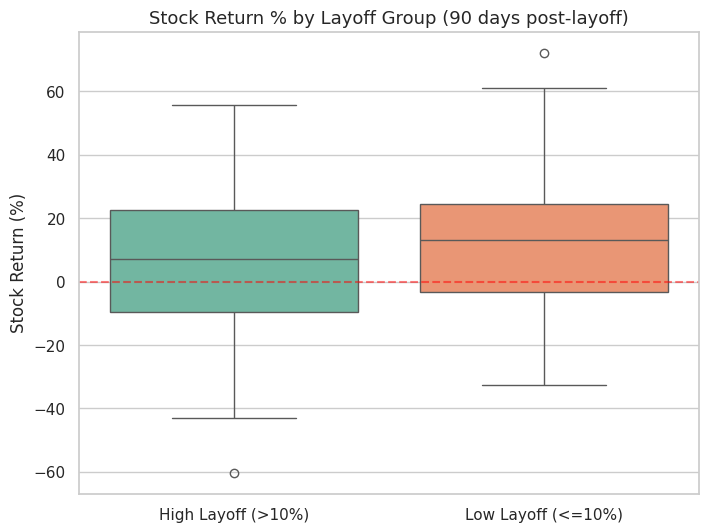

In [14]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df_clean, x='Layoff_Group', y='Return_Pct', palette='Set2')
plt.title('Stock Return % by Layoff Group (90 days post-layoff)', fontsize=13)
plt.ylabel('Stock Return (%)')
plt.xlabel('')
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.show()

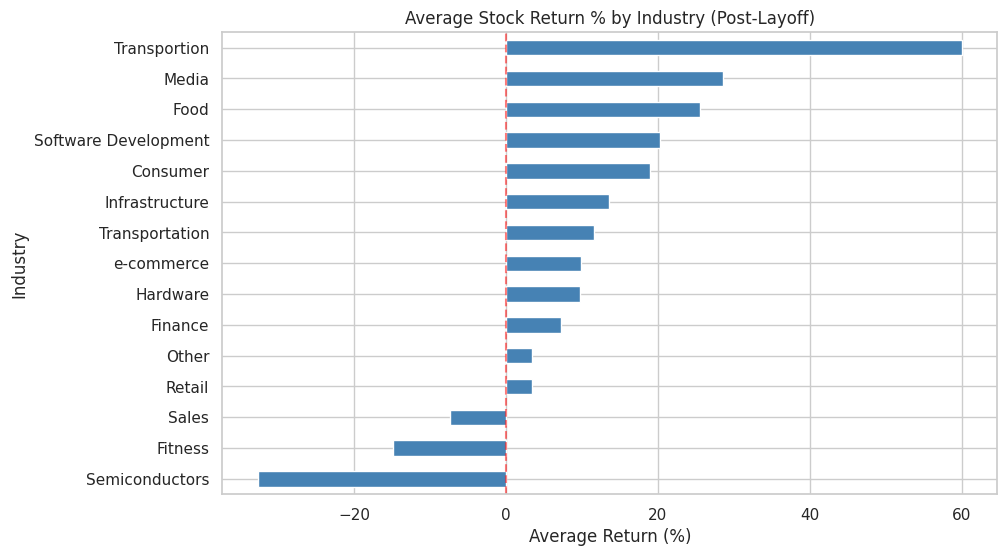

In [15]:
plt.figure(figsize=(10,6))
industry_avg = df_clean.groupby('Industry')['Return_Pct'].mean().sort_values()
industry_avg.plot(kind='barh', color='steelblue')
plt.title('Average Stock Return % by Industry (Post-Layoff)')
plt.xlabel('Average Return (%)')
plt.axvline(0, color='red', linestyle='--', alpha=0.5)
plt.show()

In [16]:
summary = df_clean.groupby('Layoff_Group')['Return_Pct'].agg(['mean', 'median', 'std', 'count']).round(2)
print(summary)

                     mean  median    std  count
Layoff_Group                                   
High Layoff (>10%)   5.86    7.11  28.97     21
Low Layoff (<=10%)  11.59   13.26  24.34     34


In [17]:
df_clean['Industry'] = df_clean['Industry'].str.strip().str.title()
industry_avg = df_clean.groupby('Industry')['Return_Pct'].mean().sort_values()
print(industry_avg)

Industry
Semiconductors         -32.690000
Fitness                -14.837500
Sales                   -7.350000
Retail                   3.471667
Other                    3.482222
Finance                  7.275000
Hardware                 9.786667
E-Commerce               9.945000
Transportation          11.610000
Infrastructure          13.643333
Consumer                18.970000
Software Development    20.230000
Food                    25.570000
Media                   28.568000
Transportion            60.080000
Name: Return_Pct, dtype: float64


In [18]:
df_clean.to_csv('layoffs_stock_analysis_final.csv', index=False)
from google.colab import files
files.download('layoffs_stock_analysis_final.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>